In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("Syn.csv")

In [3]:
data.columns = data.columns.str.strip()

In [4]:
data.shape

(1582681, 88)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1582681 entries, 0 to 1582680
Data columns (total 88 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1582681 non-null  int64  
 1   Flow ID                      1582681 non-null  object 
 2   Source IP                    1582681 non-null  object 
 3   Source Port                  1582681 non-null  int64  
 4   Destination IP               1582681 non-null  object 
 5   Destination Port             1582681 non-null  int64  
 6   Protocol                     1582681 non-null  int64  
 7   Timestamp                    1582681 non-null  object 
 8   Flow Duration                1582681 non-null  int64  
 9   Total Fwd Packets            1582681 non-null  int64  
 10  Total Backward Packets       1582681 non-null  int64  
 11  Total Length of Fwd Packets  1582681 non-null  float64
 12  Total Length of Bwd Packets  1582681 non-n

In [52]:
data_obj = data.select_dtypes(include='object')

In [53]:
list(np.array(data_obj.columns))

['Timestamp', 'SimillarHTTP', 'Label']

In [8]:
data = data.drop(columns=['Flow ID',
 'Source IP',
 'Destination IP'])

In [9]:
data = data.drop(columns=['Unnamed: 0','Source Port','Destination Port','Protocol'])

In [10]:
data_int = data.select_dtypes(include='int64')

In [11]:
data_int.shape

(1582681, 33)

<Axes: >

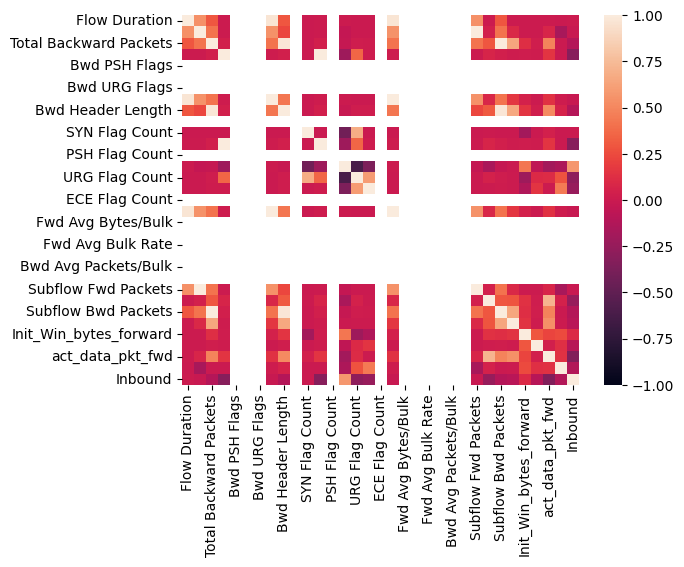

In [13]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [14]:
columns_to_drop = [
    "Total Backward Packets",
    "Subflow Fwd Packets",
    "Subflow Bwd Packets",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Packets/Bulk",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "PSH Flag Count",
    "URG Flag Count",
    "ECE Flag Count",
    "Bwd Header Length",
    "Init_Win_bytes_forward",
    "act_data_pkt_fwd",
    "Inbound"
]

In [15]:
data_int = data_int.drop(columns=columns_to_drop)

In [16]:
data_int.shape

(1582681, 18)

<Axes: >

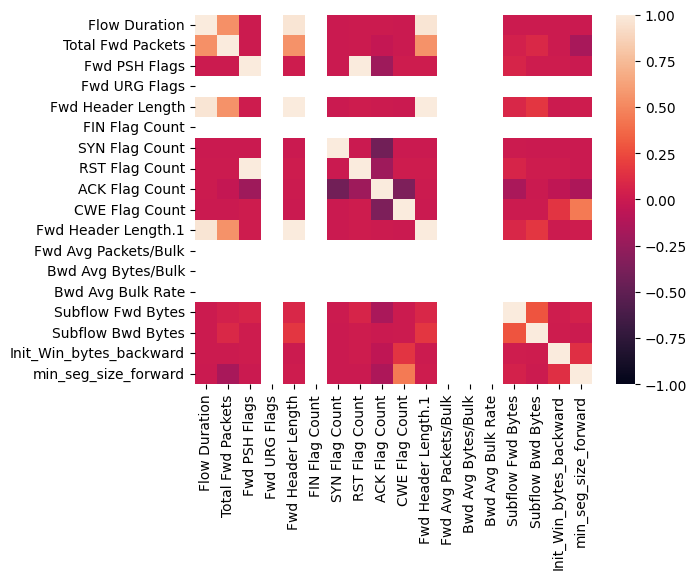

In [17]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [18]:
columns_to_drop2 = [
    "Fwd Header Length.1",
    "Total Fwd Packets",
    "Fwd PSH Flags",
    "Fwd URG Flags",
    "RST Flag Count",
    "ACK Flag Count",
    "CWE Flag Count",
    "Fwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Bulk Rate",
    "Subflow Fwd Bytes",
    "Subflow Bwd Bytes",
   "Init_Win_bytes_backward",
    "min_seg_size_forward"
]

In [19]:
data_int = data_int.drop(columns=columns_to_drop2)

<Axes: >

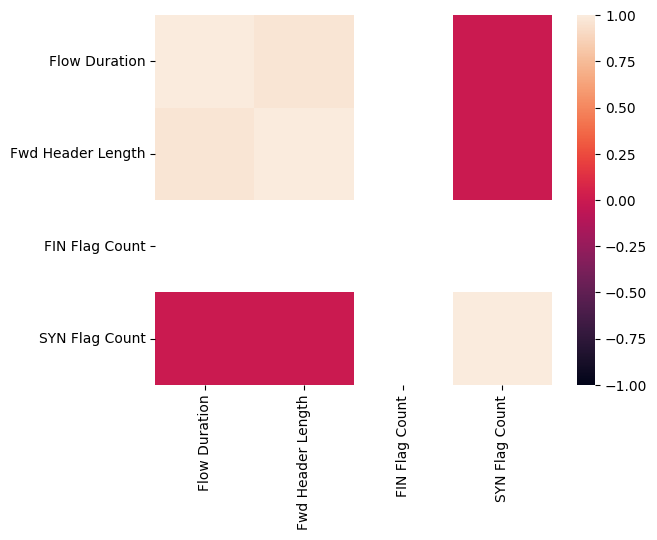

In [20]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1)

In [21]:
data_int = data_int.drop(columns="Fwd Header Length")

<Axes: >

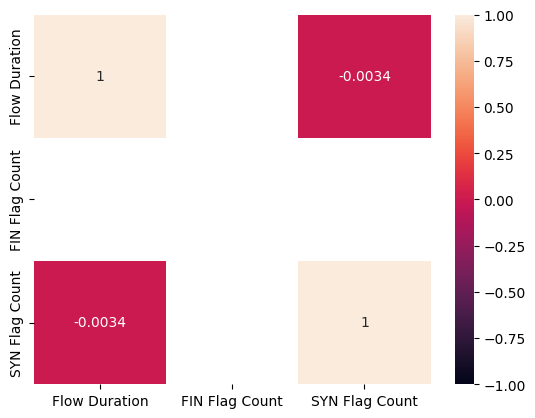

In [22]:
sns.heatmap(data_int.corr(),vmax=1,vmin=-1,annot=True)

In [23]:
data_float = data.select_dtypes(include='float64')

In [24]:
data_float.shape

(1582681, 45)

<Axes: >

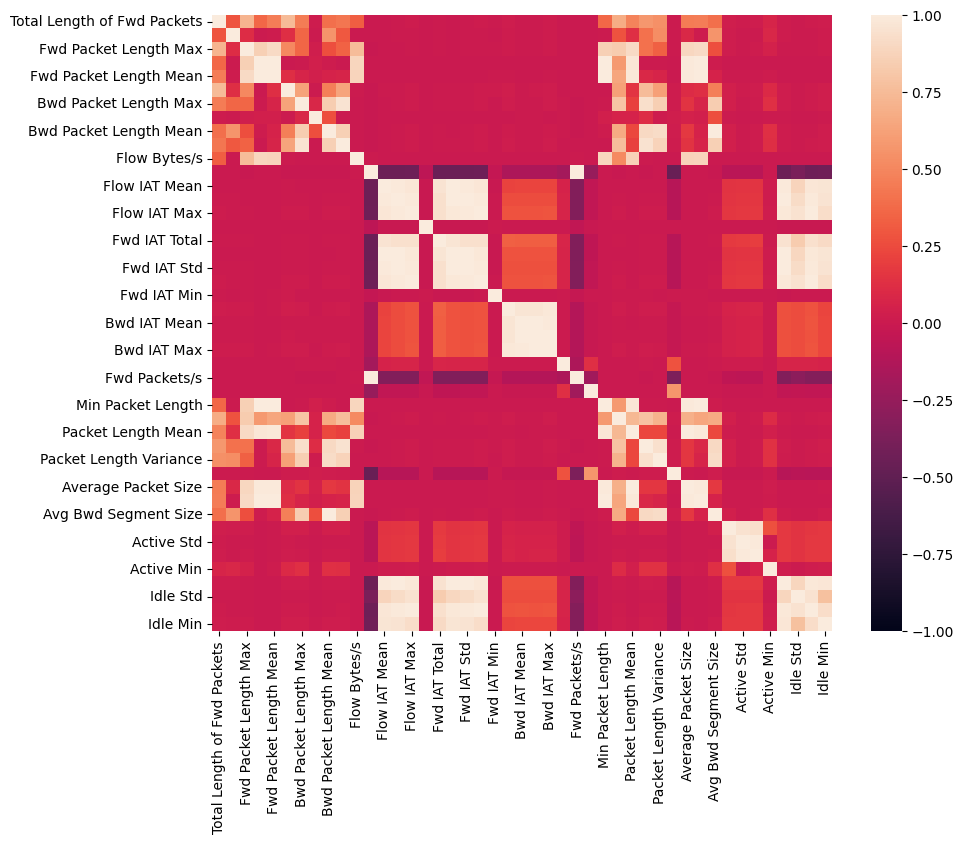

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [26]:
columns_to_drop3 = [
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Variance",
    "Average Packet Size",
    "Avg Bwd Segment Size",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Fwd IAT Total",
    "Fwd IAT Std",
    "Fwd IAT Min",
    "Bwd IAT Mean",
    "Bwd IAT Max",
    "Flow Bytes/s",
    "Min Packet Length",
   "Active Min",
    "Idle Std",
    "Idle Min"
]

In [27]:
data_float = data_float.drop(columns=columns_to_drop3)

<Axes: >

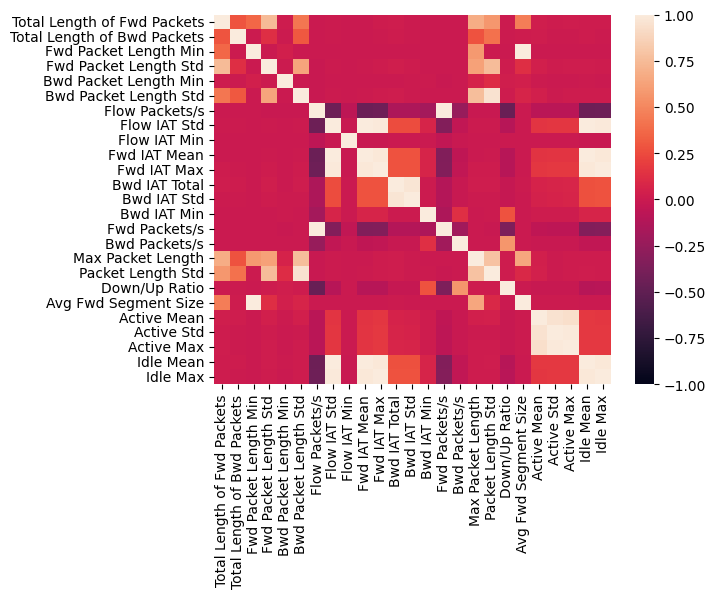

In [30]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [33]:
cols_to_remove3 = ["Total Length of Fwd Packets",
"Total Length of Bwd Packets",
"Fwd Packet Length Std",
"Bwd Packet Length Std",
"Flow IAT Std",
"Fwd IAT Max",
"Bwd IAT Std",
"Bwd Packets/s",
"Packet Length Std",
"Max Packet Length",
"Active Std",
"Active Max",
"Idle Max"]

In [34]:
data_float = data_float.drop(columns=cols_to_remove3)

<Axes: >

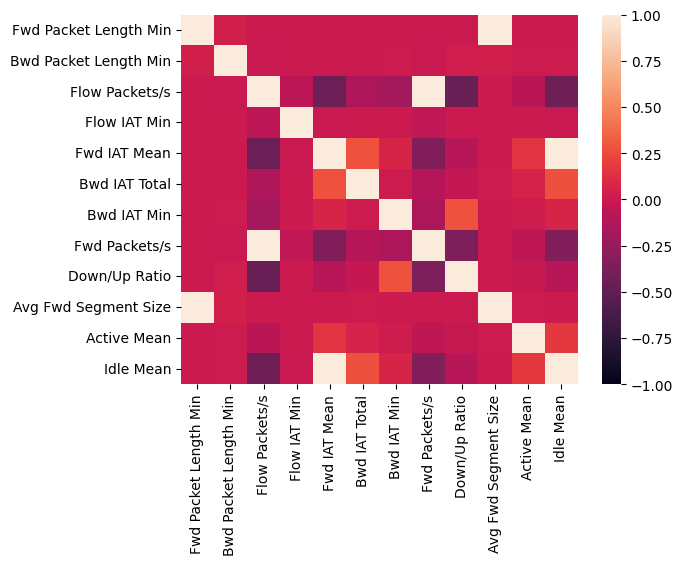

In [35]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [36]:
cols_to_remove4 = ["Fwd Packet Length Min",
"Fwd Packets/s",
"Idle Mean",
"Bwd IAT Min"]

In [37]:
data_float = data_float.drop(columns=cols_to_remove4)

<Axes: >

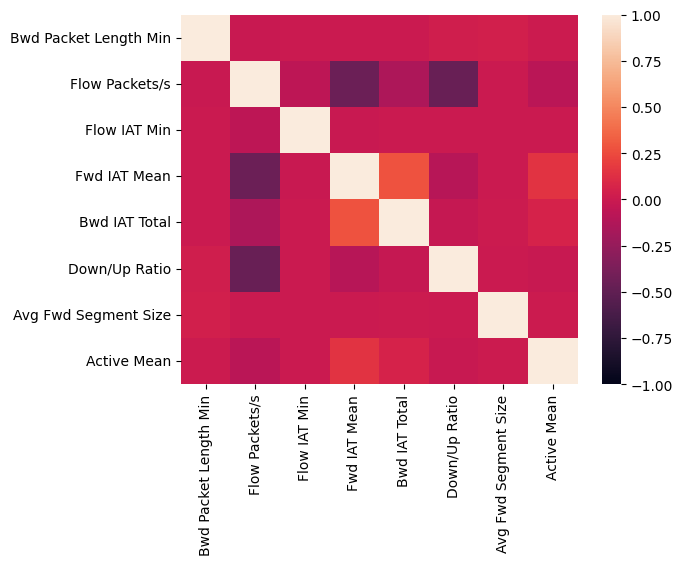

In [40]:
sns.heatmap(data_float.corr(),vmax=1,vmin=-1)

In [54]:
float_cols, int_cols, obj_cols = list(np.array(data_float.columns)), list(np.array(data_int.columns)), list(np.array(data_obj.columns))

In [55]:
data_cols = float_cols + int_cols + obj_cols

In [58]:
data_cols

['Bwd Packet Length Min',
 'Flow Packets/s',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Bwd IAT Total',
 'Down/Up Ratio',
 'Avg Fwd Segment Size',
 'Active Mean',
 'Flow Duration',
 'FIN Flag Count',
 'SYN Flag Count',
 'Timestamp',
 'SimillarHTTP',
 'Label']

In [60]:
data_final = data[data_cols]

In [63]:
data_final = data_final.set_index("Timestamp")

In [65]:
data_final['SimillarHTTP'].value_counts()

SimillarHTTP
0                                                                                                       1451609
0                                                                                                        131041
205.174.165.72/c.php                                                                                         11
talebi.ca/wp-content/plugins/spin360/spin360.css?ver=4.9.8                                                    2
talebi.ca/wp-content/themes/enfold/css/layout.css?ver=2                                                       2
talebi.ca/wp-content/themes/enfold/css/base.css?ver=2                                                         2
en-US.appex-rf.msn.com/cgtile/v1/en-US/Sports/Today.xml?cgversion=v6                                          1
en-US.appex-rf.msn.com/cgtile/v1/en-US/HealthAndFitness/Home.xml?cgversion=v6                                 1
talebi.ca/resume/                                                                          

In [67]:
data_final['SimillarHTTP'] = data_final['SimillarHTTP'].astype(str)

In [68]:
data_final["SimilarHTTP_flag"] = (data_final["SimillarHTTP"] != "0").astype(int)

In [69]:
data_final = data_final.drop(columns='SimillarHTTP')

In [71]:
data_final.to_csv("Processed_Syn.csv",index=True)